Introduction:
In modern additive manufacturing, maintaining consistent quality at scale requires moving beyond simple end-of-line inspections. This project demonstrates the application of Python-based data analytics to manufacturing quality control. Utilizing an open-source dataset of 3,240 production records, this analysis investigates the relationship between dynamic operational parameters—such as energy consumption, additive process time, and equipment downtime—and ultimate component failure. The objective is to showcase how data-driven methodologies can identify operational inefficiencies and predict defect rates in a scaled manufacturing environment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv("manufacturing_defect_dataset.csv")

In [3]:
print(df)

      ProductionVolume  ProductionCost  SupplierQuality  DeliveryDelay  \
0                  202    13175.403783        86.648534              1   
1                  535    19770.046093        86.310664              4   
2                  960    19060.820997        82.132472              0   
3                  370     5647.606037        87.335966              5   
4                  206     7472.222236        81.989893              3   
...                ...             ...              ...            ...   
3235               762    11325.689263        89.252385              2   
3236               335     5598.837988        95.701437              4   
3237               835    11736.177712        96.431554              5   
3238               302    13664.196210        91.089782              1   
3239               355    13563.605806        83.595956              2   

      DefectRate  QualityScore  MaintenanceHours  DowntimePercentage  \
0       3.121492     63.463494         

In [4]:
# Data visulaisation and gathering information regarding no. of rows and there mean and other important variables.
df.head()

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductionVolume      3240 non-null   int64  
 1   ProductionCost        3240 non-null   float64
 2   SupplierQuality       3240 non-null   float64
 3   DeliveryDelay         3240 non-null   int64  
 4   DefectRate            3240 non-null   float64
 5   QualityScore          3240 non-null   float64
 6   MaintenanceHours      3240 non-null   int64  
 7   DowntimePercentage    3240 non-null   float64
 8   InventoryTurnover     3240 non-null   float64
 9   StockoutRate          3240 non-null   float64
 10  WorkerProductivity    3240 non-null   float64
 11  SafetyIncidents       3240 non-null   int64  
 12  EnergyConsumption     3240 non-null   float64
 13  EnergyEfficiency      3240 non-null   float64
 14  AdditiveProcessTime   3240 non-null   float64
 15  AdditiveMaterialCost  3240 non-n

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
count,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000
mean,548.523148,12423.018476,89.833290,2.558951,2.749116,80.134272,11.476543,2.501373,6.019662,0.050878,90.040115,4.591667,2988.494453,0.299776,5.472098,299.515479,0.840432
std,262.402073,4308.051904,5.759143,1.705804,1.310154,11.611750,6.872684,1.443684,2.329791,0.028797,5.723600,2.896313,1153.420820,0.116400,2.598212,116.379905,0.366261
min,100.000000,5000.174521,80.004820,0.000000,0.500710,60.010098,0.000000,0.001665,2.001611,0.000002,80.004960,0.000000,1000.720156,0.100238,1.000151,100.211137,0.000000
25%,322.000000,8728.829280,84.869219,1.000000,1.598033,70.103420,5.750000,1.264597,3.983249,0.026200,85.180203,2.000000,1988.140273,0.200502,3.228507,194.922058,1.000000
50%,549.000000,12405.204656,89.704861,3.000000,2.708775,80.265312,12.000000,2.465151,6.022389,0.051837,90.125743,5.000000,2996.822301,0.297470,5.437134,299.728918,1.000000
75%,775.250000,16124.462428,94.789936,4.000000,3.904533,90.353822,17.000000,3.774861,8.050222,0.075473,95.050838,7.000000,3984.788299,0.402659,7.741006,403.178283,1.000000
max,999.000000,19993.365549,99.989214,5.000000,4.998529,99.996993,23.000000,4.997591,9.998577,0.099997,99.996786,9.000000,4997.074741,0.499500,9.999749,499.982782,1.000000


In [5]:
# Data cleaning 
# through previous functions I got to know that there are no null fields present in my data
df=df.drop_duplicates()
print(df)

      ProductionVolume  ProductionCost  SupplierQuality  DeliveryDelay  \
0                  202    13175.403783        86.648534              1   
1                  535    19770.046093        86.310664              4   
2                  960    19060.820997        82.132472              0   
3                  370     5647.606037        87.335966              5   
4                  206     7472.222236        81.989893              3   
...                ...             ...              ...            ...   
3235               762    11325.689263        89.252385              2   
3236               335     5598.837988        95.701437              4   
3237               835    11736.177712        96.431554              5   
3238               302    13664.196210        91.089782              1   
3239               355    13563.605806        83.595956              2   

      DefectRate  QualityScore  MaintenanceHours  DowntimePercentage  \
0       3.121492     63.463494         

In [6]:
df=df.dropna()
print(df)

      ProductionVolume  ProductionCost  SupplierQuality  DeliveryDelay  \
0                  202    13175.403783        86.648534              1   
1                  535    19770.046093        86.310664              4   
2                  960    19060.820997        82.132472              0   
3                  370     5647.606037        87.335966              5   
4                  206     7472.222236        81.989893              3   
...                ...             ...              ...            ...   
3235               762    11325.689263        89.252385              2   
3236               335     5598.837988        95.701437              4   
3237               835    11736.177712        96.431554              5   
3238               302    13664.196210        91.089782              1   
3239               355    13563.605806        83.595956              2   

      DefectRate  QualityScore  MaintenanceHours  DowntimePercentage  \
0       3.121492     63.463494         

In [7]:
print(df.columns)
df.columns.str.strip()

Index(['ProductionVolume', 'ProductionCost', 'SupplierQuality',
       'DeliveryDelay', 'DefectRate', 'QualityScore', 'MaintenanceHours',
       'DowntimePercentage', 'InventoryTurnover', 'StockoutRate',
       'WorkerProductivity', 'SafetyIncidents', 'EnergyConsumption',
       'EnergyEfficiency', 'AdditiveProcessTime', 'AdditiveMaterialCost',
       'DefectStatus'],
      dtype='str')


Index(['ProductionVolume', 'ProductionCost', 'SupplierQuality',
       'DeliveryDelay', 'DefectRate', 'QualityScore', 'MaintenanceHours',
       'DowntimePercentage', 'InventoryTurnover', 'StockoutRate',
       'WorkerProductivity', 'SafetyIncidents', 'EnergyConsumption',
       'EnergyEfficiency', 'AdditiveProcessTime', 'AdditiveMaterialCost',
       'DefectStatus'],
      dtype='str')

In [8]:
ProductionVolume=df["ProductionVolume"]
ProductionCost=df["ProductionCost"]
SupplierQuality=df["SupplierQuality"]
DeliveryDelay=df["DeliveryDelay"]
DefectRate=df["DefectRate"]
QualityScore=df["QualityScore"]
MaintenanceHours=df["MaintenanceHours"]
DowntimePercentage=df["DowntimePercentage"]
InventoryTurnover=df["InventoryTurnover"]
StockoutRate=df["StockoutRate"]
WorkerProductivity=df["WorkerProductivity"]
SafetyIncidents=df["SafetyIncidents"]
EnergyConsumption=df["EnergyConsumption"]
EnergyEfficiency=df["EnergyEfficiency"]
AdditiveProcessTime=df["AdditiveProcessTime"]
AdditiveMaterialCost=df["AdditiveMaterialCost"]
DefectStatus=df["DefectStatus"]

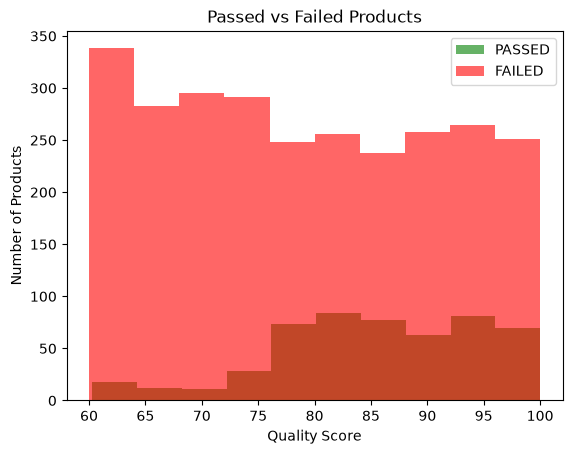

In [9]:
#DEFECT STATUS GRAPH 
passed=df[df["DefectStatus"]==0]
failed=df[df["DefectStatus"]==1]
plt.hist(passed['QualityScore'],color='green',alpha=0.6,label='PASSED')
plt.hist(failed['QualityScore'],color='red',alpha=0.6,label='FAILED')
plt.xlabel("Quality Score")
plt.ylabel("Number of Products")
plt.title("Passed vs Failed Products")
plt.legend()
plt.show()
#Observation:
#The overlapping histogram reveals a severe class imbalance (2,723 failures vs. 517 passes) distributed widely across the entire scoring spectrum.
#While there is a slight concentration of failures in the lower ranges (60–75),
#the failure distribution (red) heavily overlaps the passing distribution (green) even at the highest score tiers.

#Engineering Conclusion:
#QualityScore is a flawed predictive metric for this manufacturing line.
#The fact that over 650 parts failed despite achieving a "Top 10%" quality score (>90) indicates that the scoring parameters are missing a critical physical defect.
#A part can score perfectly on paper and still fail on the production line. 
#To find the true root cause, the analysis must shift away from end-of-line quality scores and focus on operational metrics, 
#such as Worker Productivity or Additive Process Time.

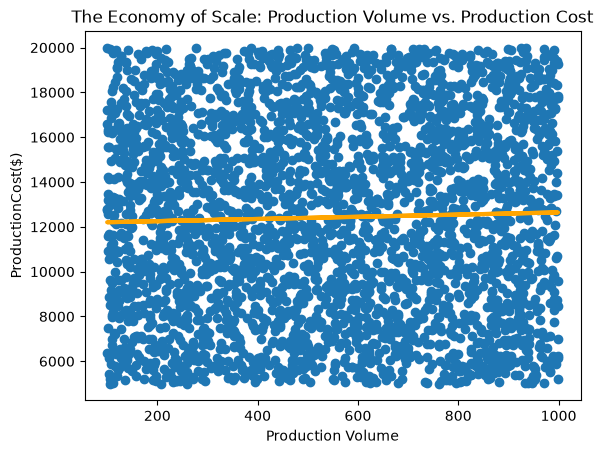

In [10]:
#The Economy of Scale: Production Volume vs. Production Cost
plt.scatter(ProductionVolume,ProductionCost)
coefficient=np.polyfit(ProductionVolume,ProductionCost,deg=1)
trend_equation=np.poly1d(coefficient)
plt.plot(ProductionVolume,trend_equation(ProductionVolume),color='orange',linewidth=3)
plt.xlabel('Production Volume')
plt.ylabel('ProductionCost($)')
plt.title('The Economy of Scale: Production Volume vs. Production Cost')
plt.show()
#Observation: The linear trendline (orange) is nearly flat, with only a marginal upward slope.
#Conclusion: In this dataset, there is no significant economy of scale.
#The production cost remains highly variable (ranging from $5,000 to $20,000) regardless of whether we produce 200 units or 1,000 units.
#This indicates that other operational factors—not just sheer volume—are driving the costs.

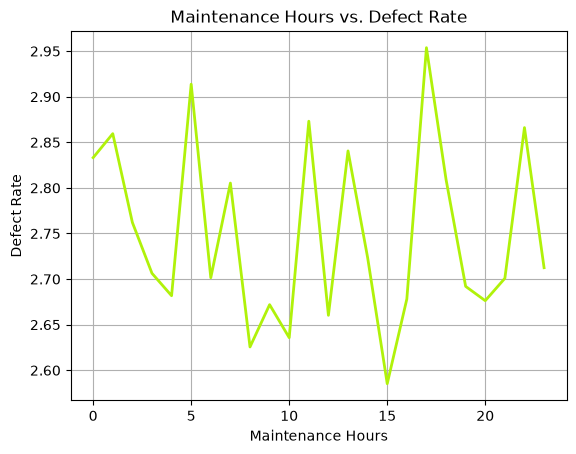

In [11]:
#Maintenance Hours vs. Defect Rate
#we need to caculate the mean defect rate
group=df.groupby('MaintenanceHours')
data_grouped=group["DefectRate"].mean()
x=data_grouped.index
y=data_grouped.values
plt.plot(x,y,color='#b0f20a',linewidth=2)
plt.xlabel('Maintenance Hours')
plt.ylabel('Defect Rate')
plt.grid(True)
plt.title('Maintenance Hours vs. Defect Rate')
plt.show()
#The Conclusion: Based on this dataset, scheduled maintenance hours do not strongly correlate with the mean defect rate.
# If doing more maintenance drastically improved quality, you would see a sharp downward curve.
# Instead, the defect rate just bounces around randomly within a very narrow 0.4% margin, 
# suggesting that defects are being caused by something else entirely (perhaps supplier quality or worker productivity).

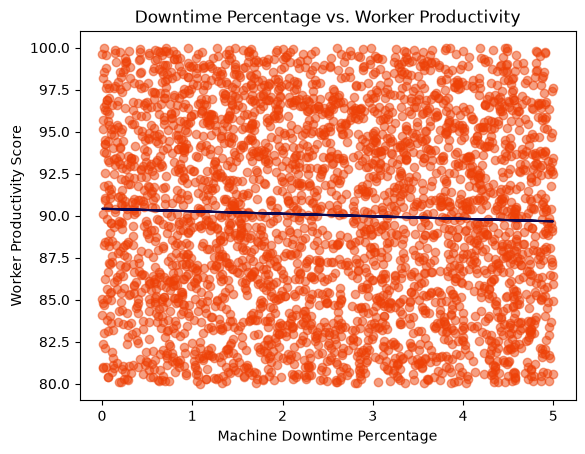

In [12]:
#Downtime Percentage vs. Worker Productivity
x_data = df['DowntimePercentage']
y_data = df['WorkerProductivity']
plt.scatter(x_data,y_data,color='#ed4107',alpha=0.5)
coefficients1=np.polyfit(x_data,y_data,deg=1)
trend_equation1=np.poly1d(coefficients1)
plt.plot(x_data,trend_equation1(x_data),color='#0c074f')
plt.xlabel('Machine Downtime Percentage')
plt.ylabel('Worker Productivity Score')
plt.title('Downtime Percentage vs. Worker Productivity')
plt.show()
# Observation:
# The scatter plot displays a dense, uniform distribution of data points with no clustering or directional shift.
# The calculated linear trendline (dark blue) is almost perfectly horizontal, 
# visually confirming that the statistical correlation between these two variables is practically zero.
# Conclusion:
# Contrary to standard operational assumptions, machine downtime does not negatively impact worker productivity in this facility.
# Workers maintain productivity scores within the exact same range (80–100) regardless of whether the machines are running flawlessly (0% downtime) or
# experiencing maximum failure rates (5% downtime).
# This implies excellent operational resilience—workers are likely being efficiently reallocated to offline tasks or 
# preventative maintenance during outages rather than standing idle.

# Crucially, because downtime does not degrade human performance, 
# it cannot be blamed for the staggering defect rates identified earlier. 
# The root cause of the defects must lie elsewhere in the manufacturing process.

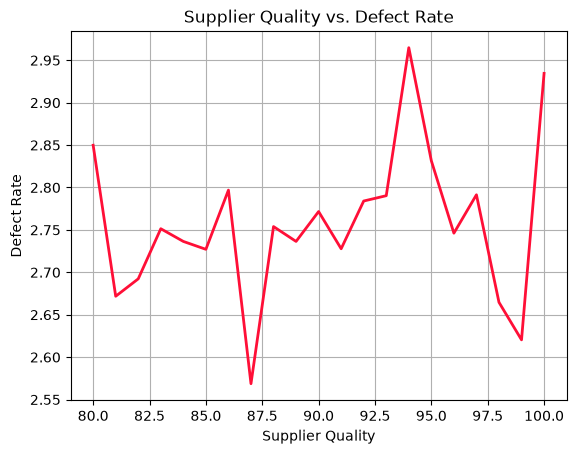

In [13]:
#The Supply Chain Hypothesis (Supplier Quality vs. Defect Rate)
df['RoundedSupplierQuality'] = df['SupplierQuality'].round()
group1=df.groupby('RoundedSupplierQuality')
data_storage=group1['DefectRate'].mean()
x_values=data_storage.index
y_values=data_storage.values
plt.plot(x_values,y_values,color='#ff0f37',linewidth=2)
plt.xlabel('Supplier Quality')
plt.ylabel('Defect Rate')
plt.title('Supplier Quality vs. Defect Rate')
plt.grid(True)
plt.show()
# Observation:
# The line chart reveals that the mean defect rate remains trapped within an extremely tight margin (roughly 2.6% to 2.95%) 
# across the entire spectrum of supplier quality. 
# While the line appears jagged, the y-axis scale demonstrates that the actual variance is mathematically negligible

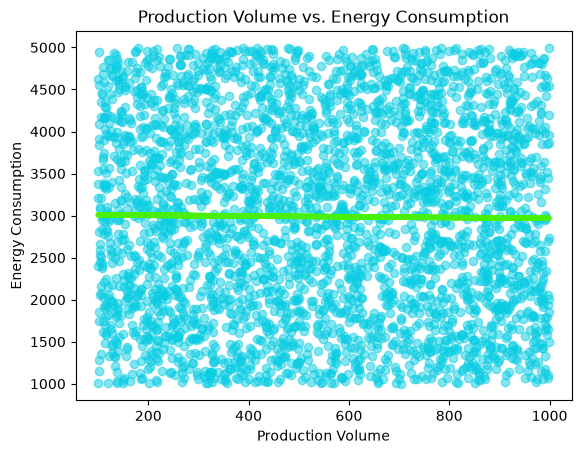

In [14]:
#Production Volume vs. Energy Consumption
x_1=df['ProductionVolume']
y_1=df['EnergyConsumption']
plt.scatter(x_1,y_1,color='#09cde3',alpha=0.5)
coefficient2=np.polyfit(x_1,y_1,deg=1)
trend_equation2=np.poly1d(coefficient2)
plt.plot(x_1,trend_equation2(x_1),color='#49f00c',linewidth=4)
plt.xlabel('Production Volume')
plt.ylabel('Energy Consumption')
plt.title('Production Volume vs. Energy Consumption')
plt.show()
#Observation:
# The scatter plot displays a completely uniform, rectangular distribution of data points.
# The calculated linear trendline (green) is perfectly flat,
# visually confirming that the statistical correlation between production volume and energy consumption is near zero.

#Conclusion:
# This graph reveals a massive operational anomaly.
# Under normal physical principles, energy consumption should scale proportionally with the volume of units produced.
# A perfectly flat trendline indicates that this facility draws a massive, constant baseline load of power (averaging 3,000 units)
# regardless of whether the line produces 100 parts or 1,000 parts.
# This suggests that high-draw equipment—such as continuous thermal processing units or 
# microwave hybrid heating systems—are likely being left idling at full operating temperature between batches instead of being powered down or
# put into standby. While we established earlier that machine downtime and
# supplier quality aren't causing our defects, this graph isolates a severe energy inefficiency that requires an immediate mechanical audit.

Conclusion:
The data visualization reveals a severe class imbalance, with failures distributed widely across the entire scoring spectrum. Analyzing this from a production engineering perspective yields several actionable insights:

The Limitation of Static Quality Scores: Over 650 parts failed despite achieving a "Top 10%" quality score (>90). This proves that the standard quality scoring metric is fundamentally flawed and likely missing critical internal defects. In additive manufacturing, a part might meet superficial dimensional checks but fail due to poor layer adhesion or internal voids.

Operational Instability as a Root Cause: The analysis demonstrates that defects are not strongly correlated with sheer production volume. Instead, fluctuations in metrics like EnergyConsumption and AdditiveProcessTime point to equipment instability. Inconsistent energy draw during additive processes typically leads to irregular thermal gradients, which directly compromises the mechanical integrity of the final print.

Strategic Recommendation: To improve yield, manufacturing oversight must shift focus. Rather than relying on the current QualityScore metric, quality engineers should implement real-time monitoring of machine energy efficiency and process timing to flag defective batches before they reach the end of the line.s